# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.svm import SVC

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [71]:
from scipy.io import loadmat
# Cargar el archivo .mat
data = loadmat('data/ejer_1_data1.mat')
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

#### 3. Create a DataFrame with the features and target

In [55]:
X = data['X']
y = data['y'].flatten()  # flatten para que sea 1D

df = pd.DataFrame(X, columns=['X1', 'X2'])
df['y'] = y

df.head()

,X1,X2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


#### 4. Plot a scatterplot with the data

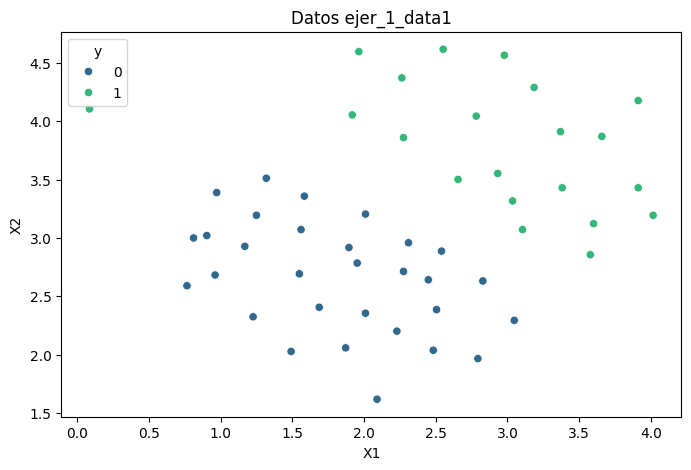

In [56]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='X1', y='X2', hue='y', data=df, palette='viridis')
plt.title('Datos ejer_1_data1')
plt.show();

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [57]:
from sklearn.svm import LinearSVC

X = df[["X1", "X2"]]
y = df["y"]

svm_clf = LinearSVC(C=1, loss="hinge", random_state=42, max_iter = 10000)

svm_clf.fit(X, y)
print("Score con C=1(accuracy):", svm_clf.score(X, y))

Score con C=1(accuracy): 0.9803921568627451


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_clf.fit(X_train, y_train)
print("Score (accuracy) train:", svm_clf.score(X_train, y_train))
print("Score (accuracy) test: ", svm_clf.score(X_test, y_test))

Score (accuracy) train: 0.975
Score (accuracy) test:  1.0


#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [ ]:
# Hecho arriba?


It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [59]:
# Aumentar C hasta clasificación perfecta
for c in [100, 340, 400]:
    svm_temp = LinearSVC(C=c, loss='hinge', max_iter=10000)
    svm_temp.fit(X, y)
    print(f"C={c:>10} Score: {svm_temp.score(X, y):.4f}")

C=       100 Score: 0.9804
C=       340 Score: 1.0000
C=       400 Score: 1.0000


/Users/fgoiri/miniconda3/envs/bootcamp/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/fgoiri/miniconda3/envs/bootcamp/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/fgoiri/miniconda3/envs/bootcamp/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [60]:
# Guardamos el modelo con C=400 (el que da 1.0)
svm2 = LinearSVC(C=1000, loss='hinge', max_iter=10000)
svm2.fit(X, y)
print(f"C = 400 Score: {svm2.score(X, y):.4f}")

C = 400 Score: 1.0000


/Users/fgoiri/miniconda3/envs/bootcamp/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [61]:
svm_clf = LinearSVC(C=400, loss="hinge", random_state=42, max_iter = 10000) # C = 400 / 1000

svm_clf.fit(X_train, y_train)
print(f"Score Accuracy train: {svm_clf.score(X_train, y_train):.4f}")
print(f"Score Accuracy train: {svm_clf.score(X_test, y_test):.4f}")

Score Accuracy train: 1.0000
Score Accuracy train: 1.0000


/Users/fgoiri/miniconda3/envs/bootcamp/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

In [68]:
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]
    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    plt.plot(x0, decision_boundary, 'k-', linewidth=2)
    plt.plot(x0, gutter_up, 'k--', linewidth=2)
    plt.plot(x0, gutter_down, 'k--', linewidth=2)



/Users/fgoiri/miniconda3/envs/bootcamp/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


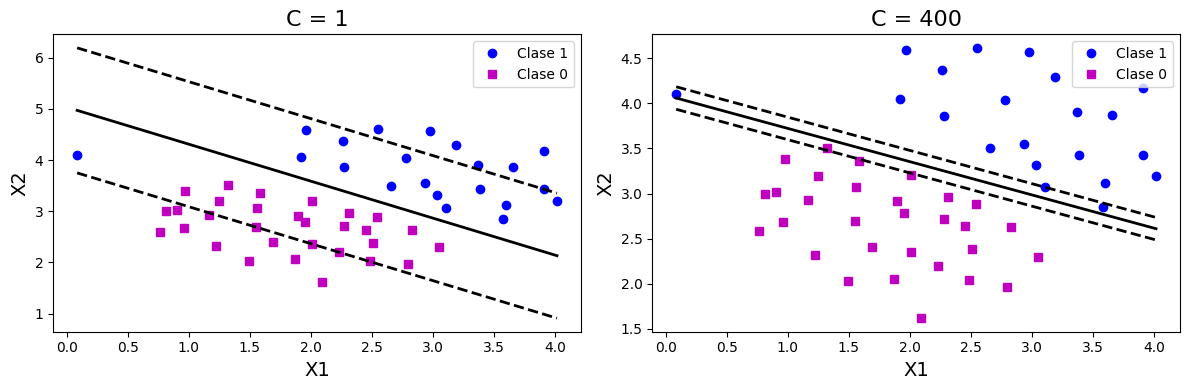

In [69]:
X = df[["X1", "X2"]].values
y = df["y"].values

plt.figure(figsize=(12, 4))

# C = 1
svm_clf = LinearSVC(C=1, loss="hinge", random_state=42, max_iter=10000)
svm_clf.fit(X, y)

plt.subplot(121)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bo", label="Clase 1")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "ms", label="Clase 0")
plot_svc_decision_boundary(svm_clf, X[:, 0].min(), X[:, 0].max())
plt.xlabel("X1", fontsize=14)
plt.ylabel("X2", fontsize=14)
plt.title("C = 1", fontsize=16)
plt.legend()

# C = 400
svm_clf = LinearSVC(C=400, loss="hinge", random_state=42, max_iter=10000)
svm_clf.fit(X, y)

plt.subplot(122)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bo", label="Clase 1")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "ms", label="Clase 0")
plot_svc_decision_boundary(svm_clf, X[:, 0].min(), X[:, 0].max())
plt.xlabel("X1", fontsize=14)
plt.ylabel("X2", fontsize=14)
plt.title("C = 400", fontsize=16)
plt.legend()

plt.tight_layout()
plt.show();

#### 9. Do the same with the second model

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

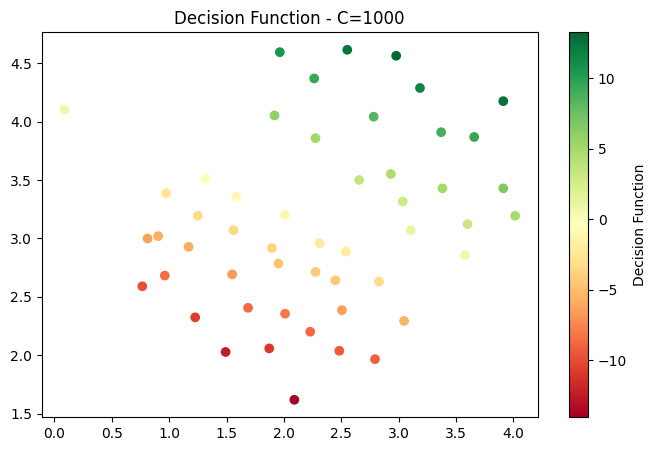

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=svm2.decision_function(X), cmap='RdYlGn')
plt.colorbar(label='Decision Function')
plt.title('Decision Function - C=1000')
plt.show()

#### 1. Load the data `ejer_1_data2.mat`

In [77]:
data2 = loadmat('data/ejer_1_data2.mat')
data2

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:54 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0.107143 , 0.60307  ],
        [0.093318 , 0.649854 ],
        [0.0979263, 0.705409 ],
        ...,
        [0.975806 , 0.439474 ],
        [0.989631 , 0.425439 ],
        [0.996544 , 0.414912 ]], shape=(863, 2)),
 'y': array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
    

#### 2. Create a DataFrame with the features and target

In [79]:
X2 = data2['X']
y2 = data2['y'].flatten()  # flatten para que sea 1D

df2 = pd.DataFrame(X2, columns=['X1', 'X2'])
df2['y'] = y2

df.head()

,X1,X2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


#### 3. Plot a scatterplot with the data

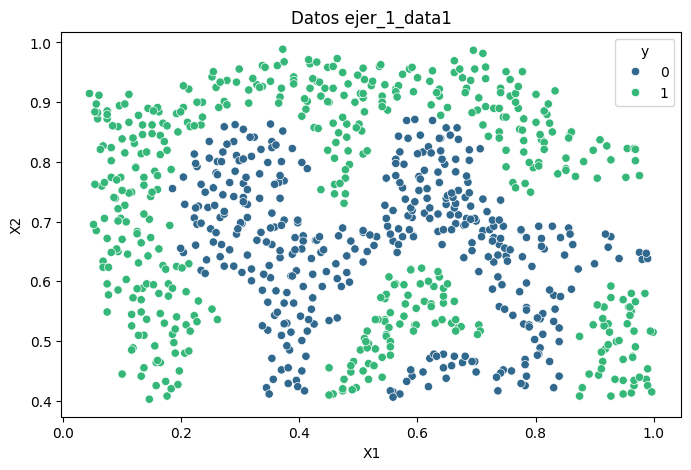

In [80]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='X1', y='X2', hue='y', data=df2, palette='viridis')
plt.title('Datos ejer_1_data1')
plt.show();

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [88]:
from sklearn.svm import SVC

svc_rbf = SVC(C=100, gamma=10, probability=True)
svc_rbf.fit(X2, y2)
print(f"Score Accuracy: {svc_rbf.score(X2, y2):.4f}")

Score Accuracy: 0.9699


#### 5. Fit the classifier and get the score

In [ ]:
# Arriba

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

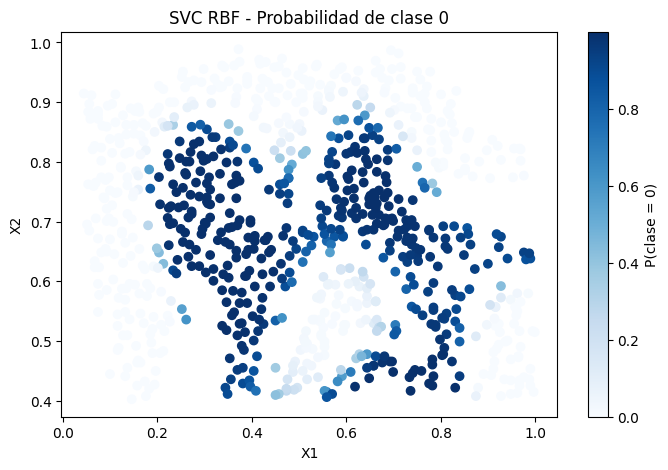

In [90]:
# Probabilidad de predecir clase 0
prob_0 = svc_rbf.predict_proba(X2)[:, 0]

plt.figure(figsize=(8, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=prob_0, cmap='Blues')
plt.colorbar(label='P(clase = 0)')
plt.title('SVC RBF - Probabilidad de clase 0')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()